# 4. Evaluation orchestration for mixed 1-D and n-D inputs

`EvaluationOrchestrator` accepts any mix of inputs. For each case it runs the frozen pipeline,
reads the planner's route and scores only what that route supports:

| Route | Detection metrics | Localization metrics |
| --- | --- | --- |
| 1-D | hit / miss / early alarm / false alarm / correct rejection, delay | – (not identifiable) |
| n-D | same | rank of the true source for heuristic, GNN and GAT → Top-1, Top-3, MRR |

Cases without ground truth are still run and reported as `unlabelled`.

In [1]:
# If the package is not installed yet (run once, then restart the kernel):
# %pip install "graph-evt-agent[notebooks] @ git+https://github.com/D2718281828nis/Graph-EVT-agent"
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42

In [2]:
from graph_evt_agent import (EVTConfig, GraphConfig, GraphEVTPipeline, EpisodeLabeler,
                             EvaluationCase, EvaluationOrchestrator, GraphLearningConfig,
                             ProcessModelTrainer)
from graph_evt_agent.synthetic import (make_propagation_episode, make_recording,
                                       make_univariate_episode)
from graph_evt_agent import visualization as viz

evt, graph = EVTConfig(baseline_size=400, persistence=3), GraphConfig(method="ar", edge_threshold=0.2)
# Train a process model on separate recordings (see notebook 3)
train_recordings = {f"rec{i}": make_recording(10, 6, amplitude=8, gain_jitter=0.8, seed=100 + i)
                    for i in range(10)}
labels = EpisodeLabeler(GraphEVTPipeline(evt, graph)).label(
    {k: r.as_input() for k, r in train_recordings.items()},
    {k: list(zip(r.event_times, r.sources)) for k, r in train_recordings.items()})
model = ProcessModelTrainer(GraphLearningConfig(epochs=80, random_state=SEED)).train(labels).model

## Push a mixed batch of test inputs

In [3]:
cases = []
for i in range(30):                                   # n-D with known source
    ep = make_propagation_episode(6, source=i % 6, amplitude=8, gain_jitter=0.8, seed=500 + i)
    cases.append(EvaluationCase.from_synthetic(ep, case_id=f"nd_{i}"))
for i in range(10):                                   # 1-D with an event
    cases.append(EvaluationCase.from_synthetic(make_univariate_episode(seed=600 + i), f"1d_event_{i}"))
for i in range(10):                                   # 1-D without an event
    ep = make_univariate_episode(seed=700 + i, amplitude=0)
    cases.append(EvaluationCase(ep.values[:, 0], event_time=None, case_id=f"1d_quiet_{i}"))
cases.append(make_propagation_episode(6, source=1, seed=900).values)  # raw input, no truth

orchestrator = EvaluationOrchestrator(
    GraphEVTPipeline(evt, graph, process_model=model), early_tolerance=0, k=3, verbose=True)
report = orchestrator.evaluate(cases)

Evaluating cases:   0%|          | 0/51 [00:00<?, ?it/s]

Evaluating cases:  12%|█▏        | 6/51 [00:00<00:00, 59.11it/s, nd_5: n-d hit]

Evaluating cases:  24%|██▎       | 12/51 [00:00<00:00, 59.32it/s, nd_11: n-d hit]

Evaluating cases:  35%|███▌      | 18/51 [00:00<00:00, 45.70it/s, nd_17: n-d hit]

Evaluating cases:  49%|████▉     | 25/51 [00:00<00:00, 52.04it/s, nd_24: n-d hit]

Evaluating cases:  69%|██████▊   | 35/51 [00:00<00:00, 66.25it/s, 1d_event_4: 1-d hit]

Evaluating cases:  88%|████████▊ | 45/51 [00:00<00:00, 71.45it/s, 1d_quiet_4: 1-d correct_rejection]

Evaluating cases: 100%|██████████| 51/51 [00:00<00:00, 65.03it/s, case_50: n-d unlabelled]          

In [4]:
pd.DataFrame(report.to_records()).head(10)

,case_id,route,outcome,stop_reason,detected_time,true_event_time,delay,true_source,heuristic_source,heuristic_rank,gnn_source,gnn_rank,gat_source,gat_rank
0,nd_0,n-d,hit,NaN,423.0,420.0,3.0,0.0,5.0,4.0,0.0,1.0,0.0,1.0
1,nd_1,n-d,hit,NaN,423.0,420.0,3.0,1.0,2.0,2.0,2.0,3.0,2.0,3.0
2,nd_2,n-d,hit,NaN,420.0,420.0,0.0,2.0,2.0,1.0,2.0,1.0,2.0,1.0
3,nd_3,n-d,hit,NaN,423.0,420.0,3.0,3.0,1.0,4.0,2.0,3.0,2.0,3.0
4,nd_4,n-d,hit,NaN,420.0,420.0,0.0,4.0,4.0,1.0,4.0,1.0,4.0,1.0
5,nd_5,n-d,hit,NaN,423.0,420.0,3.0,5.0,4.0,6.0,4.0,6.0,4.0,6.0
6,nd_6,n-d,hit,NaN,425.0,420.0,5.0,0.0,2.0,4.0,2.0,2.0,1.0,2.0
7,nd_7,n-d,hit,NaN,420.0,420.0,0.0,1.0,1.0,1.0,0.0,2.0,0.0,3.0
8,nd_8,n-d,hit,NaN,420.0,420.0,0.0,2.0,2.0,1.0,2.0,1.0,2.0,1.0
9,nd_9,n-d,hit,NaN,422.0,420.0,2.0,3.0,4.0,2.0,3.0,1.0,3.0,1.0


In [5]:
pd.DataFrame(report.summary()).round(3)

,1-d,n-d
cases,20.0,31.000
hit,10.0,30.000
miss,0.0,0.000
early_alarm,0.0,0.000
false_alarm,0.0,0.000
correct_rejection,10.0,0.000
unlabelled,0.0,1.000
detection_rate,1.0,1.000
false_alarm_rate,0.0,NaN
mean_delay,0.0,1.467


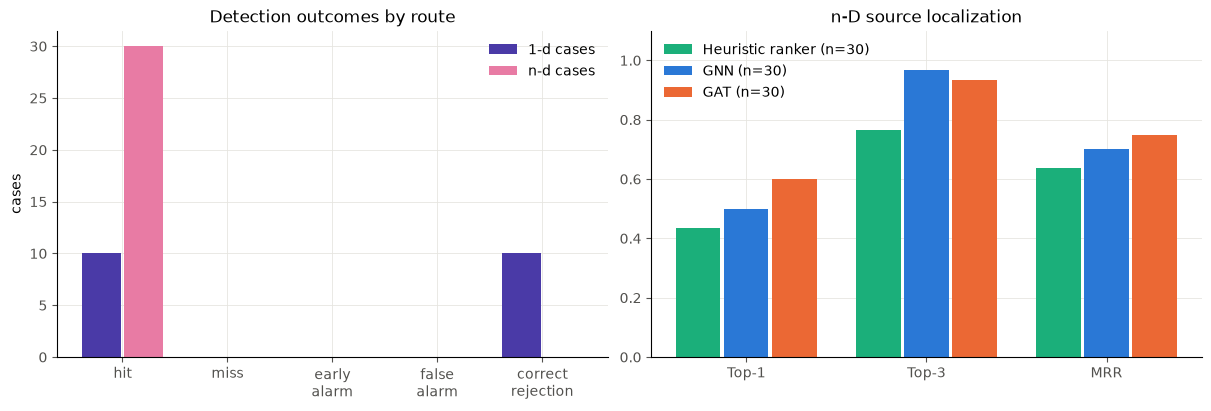

In [6]:
fig = viz.plot_evaluation(report)

## Embedding progress in another program

`verbose=2` also shows nested bars (each case's pipeline stages). For GUIs, services or logs,
pass a `progress_callback`; it receives `ProgressEvent(desc, step, total, message, elapsed)`.

In [7]:
import logging
logging.basicConfig(level=logging.INFO, format="%(message)s", force=True)
log = logging.getLogger("my_app")

def on_progress(event):
    log.info("%s %d/%d (%.0f%%) %s", event.desc, event.step, event.total,
             100 * event.fraction, event.message)

quiet = EvaluationOrchestrator(GraphEVTPipeline(evt, graph), progress_callback=on_progress)
_ = quiet.evaluate(cases[:3])

Graph-EVT pipeline 1/5 (20%) input multivariate (600, 6)


Graph-EVT pipeline 2/5 (40%) stationary baseline


Graph-EVT pipeline 3/5 (60%) event at 423


Graph-EVT pipeline 4/5 (80%) ar_innovation_correlation: 6 edges


Graph-EVT pipeline 5/5 (100%) source ch5


...

Graph-EVT pipeline 2/5 (40%) stationary baseline


Graph-EVT pipeline 3/5 (60%) event at 420


Graph-EVT pipeline 4/5 (80%) ar_innovation_correlation: 9 edges


Graph-EVT pipeline 5/5 (100%) source ch2


Evaluating cases 3/3 (100%) nd_2: n-d hit


## Good practice

* Freeze every configuration (baseline length, tail quantile, graph method, labelling
  thresholds, model hyper-parameters) **before** the final evaluation.
* Split by subject/device/recording, never by samples of one episode.
* Report confidence intervals over independent episodes and compare against the heuristic
  and simple baselines. Synthetic scores here demonstrate behavior, not real-world accuracy.